# 4 Codificación posicional

**Positional encoding:** $\;$ dado un embedding del texto de entrada $\,X\in\mathbb{R}^{n\times d_{\text{model}}},\,$ multiplica $\,X\,$ por $\,\sqrt{d_{\text{model}}}\,$ y añade una secuencia de posiciones absolutas representadas mediante senos y cosenos
$$\operatorname{PE}(X)%
=X\sqrt{d_{\text{model}}}+\begin{pmatrix}
\operatorname{PE}_{(0, 0)}&\cdots&\operatorname{PE}_{(0, d_{\text{model}}-1)}\\
\vdots&\vdots&\vdots\\
\operatorname{PE}_{(n-1, 0)}&\cdots&\operatorname{PE}_{(n-1, d_{\text{model}}-1)}\\
\end{pmatrix}$$
donde
$$\begin{align*}
\operatorname{PE}_{(\text{pos}, 2i)}%
&=\sin\left(\frac{\text{pos}}{10000^{2i/{d_{\text{model}}}}}\right)\\
\operatorname{PE}_{(\text{pos}, 2i+1)}%
&=\cos\left(\frac{\text{pos}}{10000^{2i/{d_{\text{model}}}}}\right)
\end{align*}$$

**Ejercicio:** $\;$ añade codificación posicional a $\,X=\begin{pmatrix}0.0293&0.8776\\0.3191&-0.8395\\0.0293&0.8776\end{pmatrix}$


<p style="page-break-after:always;"></p>


**Solución:**
$$\begin{align*}
\operatorname{PE}_{(0, 0)}&=\sin\left(\frac{0}{10000^{0/2}}\right)=0
&\operatorname{PE}_{(0, 1)}&=\cos\left(\frac{0}{10000^{0/2}}\right)=1\\
\operatorname{PE}_{(1, 0)}&=\sin\left(\frac{1}{10000^{0/2}}\right)=0.8415%
&\operatorname{PE}_{(1, 1)}&=\cos\left(\frac{1}{10000^{0/2}}\right)=0.5403\\%
\operatorname{PE}_{(2, 0)}&=\sin\left(\frac{2}{10000^{0/2}}\right)=0.9093
&\operatorname{PE}_{(2, 1)}&=\cos\left(\frac{2}{10000^{0/2}}\right)=-0.4161%
\end{align*}$$
$$\operatorname{PE}(X)%
=\begin{pmatrix}0.0293&0.8776\\0.3191&-0.8395\\0.0293&0.8776\end{pmatrix}\sqrt{2}+%
\begin{pmatrix}0&1\\0.8415&0.5403\\0.9093&-0.4161\end{pmatrix}%
=\begin{pmatrix}0.0415&2.2411\\1.2927&-0.6469\\0.9508&0.8249\end{pmatrix}$$

In [1]:
import torch; import torch.nn as nn; torch.manual_seed(23)
import import_ipynb; from at251 import create_model, create_fixed_positional_encoding
model = create_model(src_vocab_size=3, tgt_vocab_size=3, embed_dim=2, num_layers=1, num_heads=1, dropout=0.)

In [2]:
src = torch.LongTensor([[1, 2, 1]]); model.src_embed.embed(src).data

tensor([[[ 0.0293,  0.8776],
         [ 0.3191, -0.8395],
         [ 0.0293,  0.8776]]])

In [3]:
pe = create_fixed_positional_encoding(dim=2, max_len=3); pe

tensor([[[ 0.0000,  1.0000],
         [ 0.8415,  0.5403],
         [ 0.9093, -0.4161]]])

In [4]:
model.src_embed(src).data

tensor([[[ 0.0415,  2.2411],
         [ 1.2927, -0.6469],
         [ 0.9508,  0.8249]]])


<p style="page-break-after:always;"></p>


**Continuidad de la codificación posicional:** $\;$ veamos el caso $\,n=100\,$ y `d_model = 512`

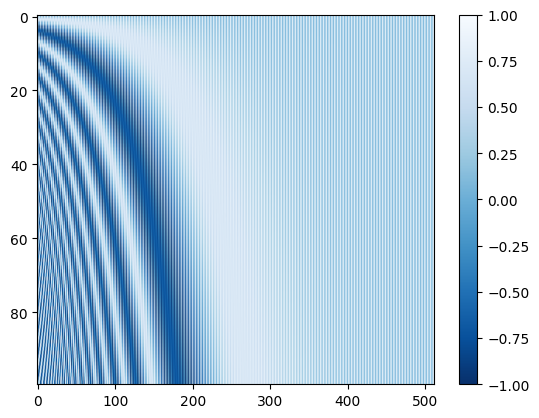

In [5]:
import matplotlib.pyplot as plt
pe = create_fixed_positional_encoding(512, 100)
plt.imshow(*pe, aspect='auto', origin='upper', cmap='Blues_r'); plt.colorbar();


<p style="page-break-after:always;"></p>
